In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
import os 
import random
import math

In [3]:
train_csv_path = "/home/mohammmad/Traffic-Sign-Recognition /data/Train.csv"
train_df = pd.read_csv(train_csv_path)
train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
test_csv_path = "/home/mohammmad/Traffic-Sign-Recognition /data/Test.csv"
test_df = pd.read_csv(test_csv_path)
test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


**Class Distribution**

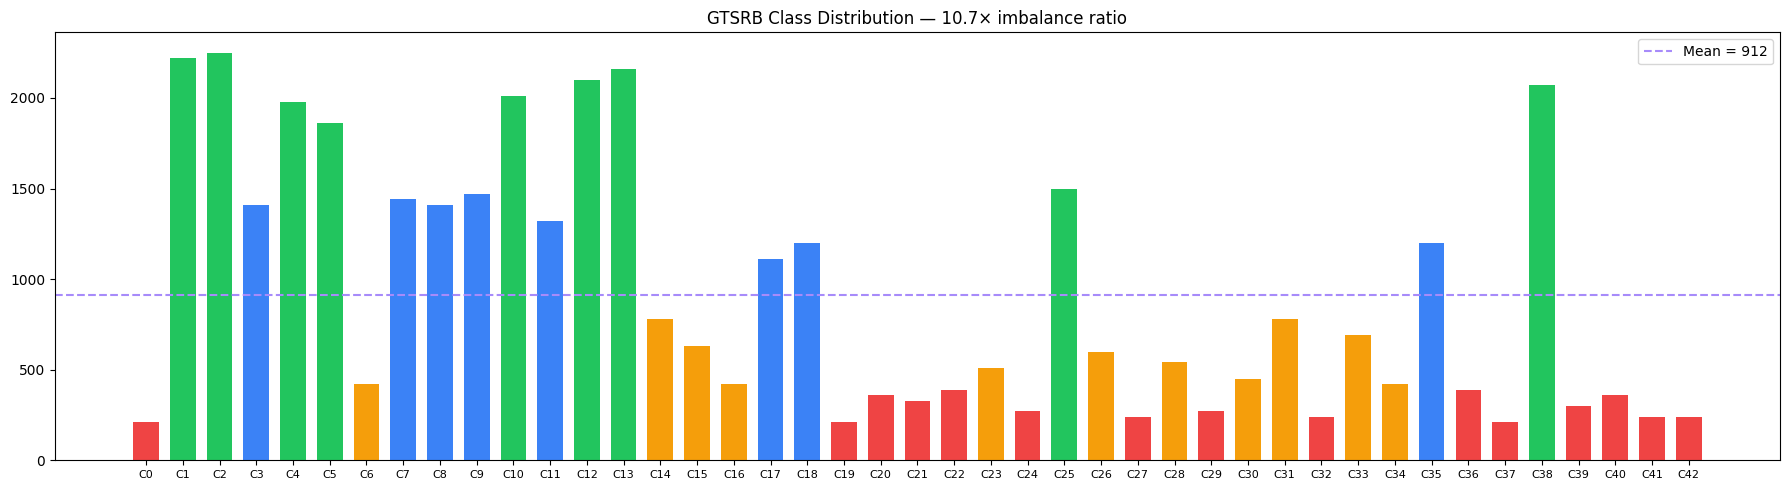

In [ ]:
df = pd.read_csv(train_csv_path)
counts = df["ClassId"].value_counts().sort_index()

# Color by tier
def tier_color(n):
    if n >= 1500: return "#22c55e"
    if n >= 800:  return "#3b82f6"
    if n >= 400:  return "#f59e0b"
    return "#ef4444"  # critical minority

colors = [tier_color(counts[i]) for i in range(43)]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(43), counts.values, color=colors, width=0.7)
ax.axhline(counts.mean(), color="#a78bfa", linestyle="--", label=f"Mean = {counts.mean():.0f}")
ax.set_xticks(range(43))
ax.set_xticklabels([f"C{i}" for i in range(43)], fontsize=8)
ax.set_title("GTSRB Class Distribution — 10.7× imbalance ratio")
ax.legend()
plt.tight_layout()
# plt.savefig("class_distribution.png", dpi=150)

**Sample Of All Classes**

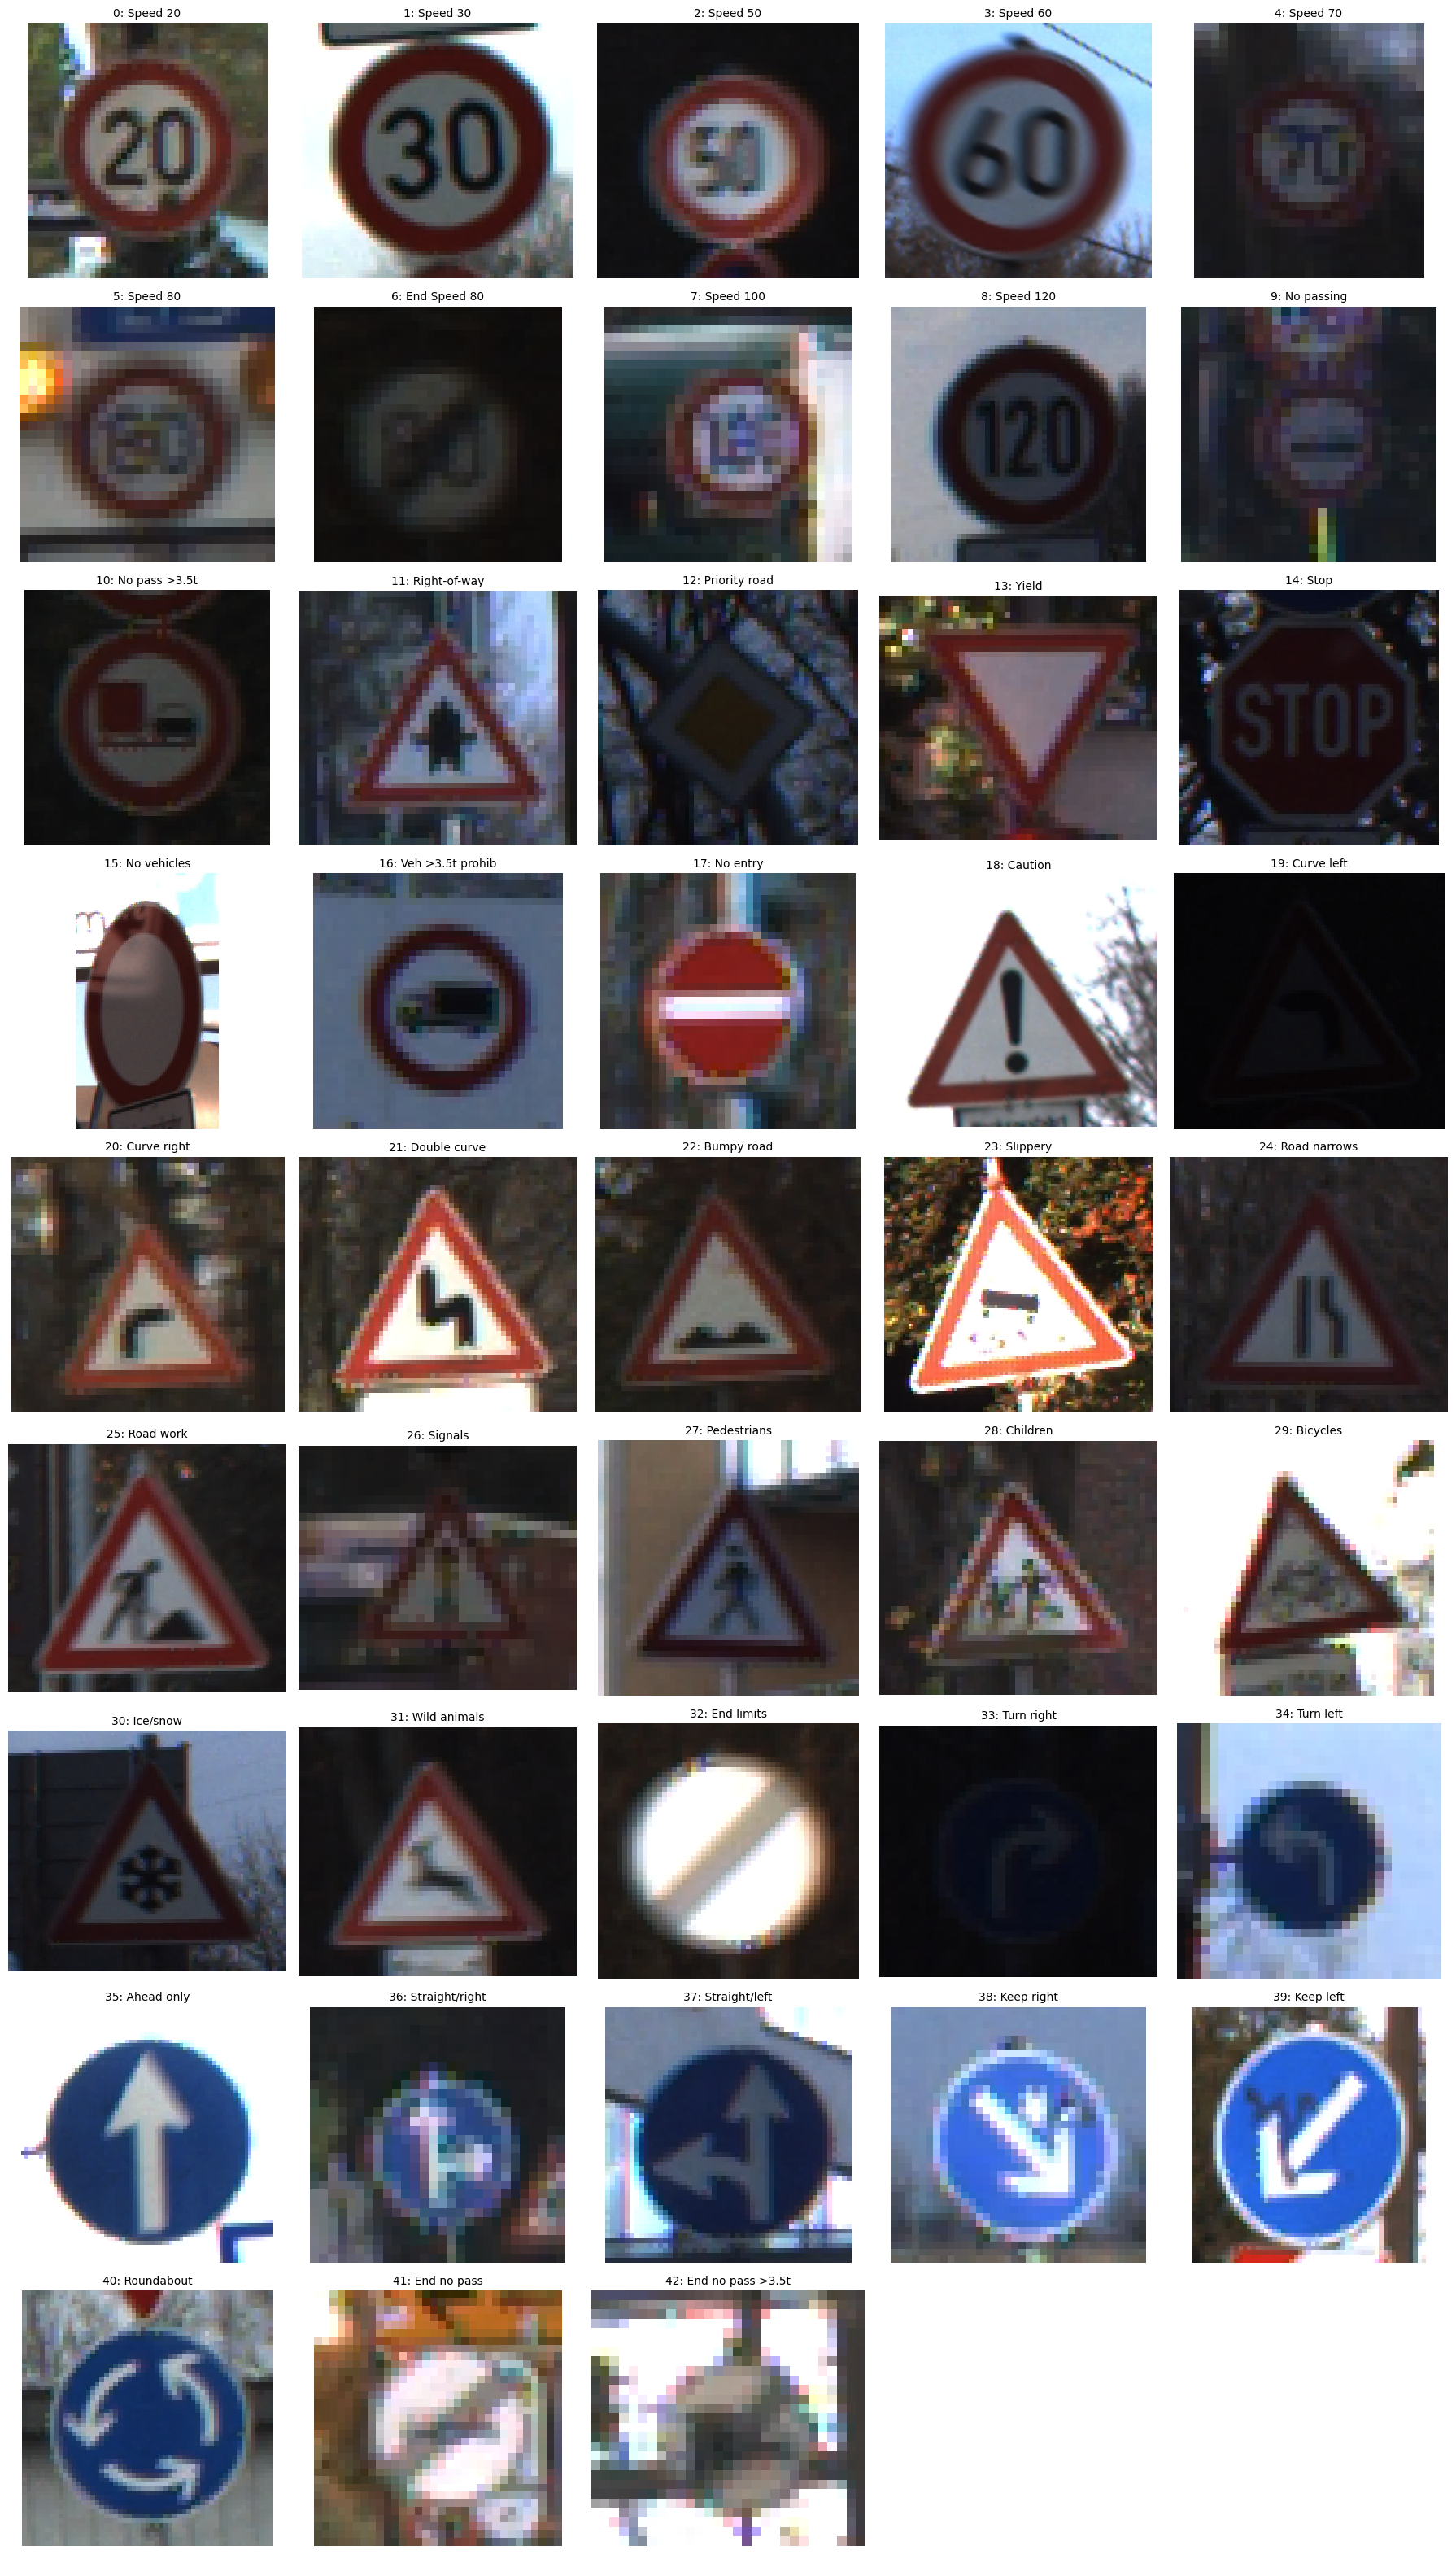

In [18]:
CLASS_NAMES = [
    "Speed 20", "Speed 30", "Speed 50", "Speed 60", "Speed 70", "Speed 80",
    "End Speed 80", "Speed 100", "Speed 120", "No passing", "No pass >3.5t",
    "Right-of-way", "Priority road", "Yield", "Stop", "No vehicles",
    "Veh >3.5t prohib", "No entry", "Caution", "Curve left", "Curve right",
    "Double curve", "Bumpy road", "Slippery", "Road narrows", "Road work",
    "Signals", "Pedestrians", "Children", "Bicycles", "Ice/snow",
    "Wild animals", "End limits", "Turn right", "Turn left", "Ahead only",
    "Straight/right", "Straight/left", "Keep right", "Keep left",
    "Roundabout", "End no pass", "End no pass >3.5t"
]

# change this to your dataset path
dataset_path = "data/train"

num_classes = len(CLASS_NAMES)
cols = 5
rows = math.ceil(num_classes / cols)

plt.figure(figsize=(18, rows * 3.5))

for class_idx in range(num_classes):
    class_folder = os.path.join(dataset_path, str(class_idx))
    
    # get all image files from the folder
    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
    ]
    
    if not image_files:
        print(f"No images found in class {class_idx}")
        continue
    
    random_image = random.choice(image_files)
    image_path = os.path.join(class_folder, random_image)
    
    img = Image.open(image_path)
    
    plt.subplot(rows, cols, class_idx + 1)
    plt.imshow(img)
    plt.title(f"{class_idx}: {CLASS_NAMES[class_idx]}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

****image size distribution****

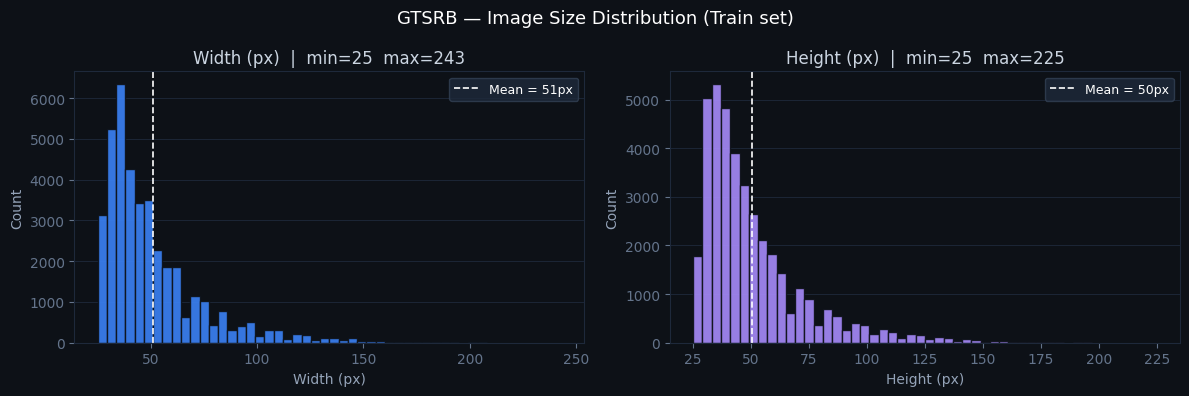

In [ ]:
DATA_DIR = "data"
df = pd.read_csv(f"{DATA_DIR}/Train.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("GTSRB — Image Size Distribution (Train set)", color="white", fontsize=13)

for ax, col, color, label in [
    (axes[0], "Width",  "#3b82f6", "Width (px)"),
    (axes[1], "Height", "#a78bfa", "Height (px)"),
]:
    ax.set_facecolor("#0d1117")
    ax.hist(df[col], bins=50, color=color, edgecolor="#0d1117", alpha=0.9)
    ax.axvline(df[col].mean(), color="white", linestyle="--", linewidth=1.2,
               label=f"Mean = {df[col].mean():.0f}px")
    ax.set_xlabel(label, color="#94a3b8")
    ax.set_ylabel("Count", color="#94a3b8")
    ax.set_title(f"{label}  |  min={df[col].min()}  max={df[col].max()}", color="#cbd5e1")
    ax.tick_params(colors="#64748b")
    ax.legend(fontsize=9, labelcolor="white", facecolor="#1e293b", edgecolor="#334155")
    for spine in ax.spines.values():
        spine.set_color("#1e293b")
    ax.yaxis.grid(True, color="#1e293b", linewidth=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig("size_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

**ROI crops vs raw images**

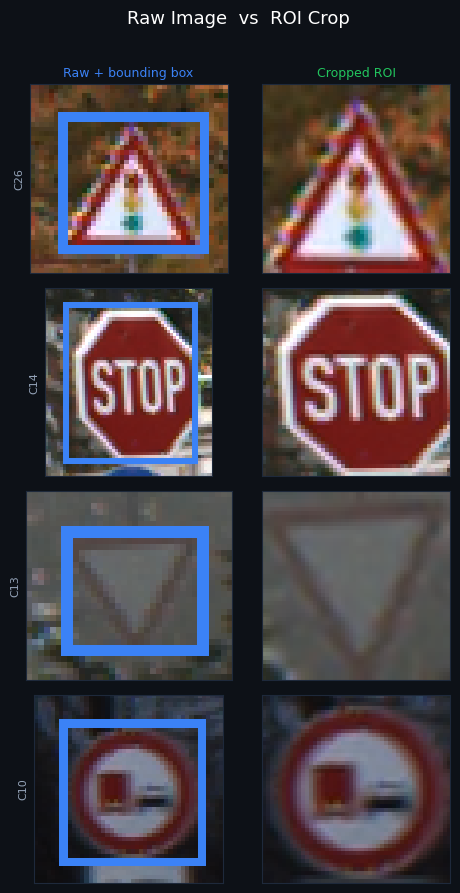

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/Train.csv")
df["Path"] = df["Path"].str.replace("Train/", "train/", regex=False)

N = 4  # number of examples
samples = df.sample(N, random_state=42)

fig, axes = plt.subplots(N, 2, figsize=(5, N * 2.2))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("Raw Image  vs  ROI Crop", color="white", fontsize=13, y=1.01)
axes[0][0].set_title("Raw + bounding box", color="#3b82f6", fontsize=9)
axes[0][1].set_title("Cropped ROI", color="#22c55e", fontsize=9)

for i, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(f"{DATA_DIR}/{row['Path']}").convert("RGB")
    x1, y1, x2, y2 = int(row["Roi.X1"]), int(row["Roi.Y1"]), int(row["Roi.X2"]), int(row["Roi.Y2"])

    # Left: raw image with bounding box drawn on it
    raw = img.copy()
    draw = ImageDraw.Draw(raw)
    draw.rectangle([x1, y1, x2, y2], outline=(59, 130, 246), width=2)
    axes[i][0].imshow(np.array(raw))
    axes[i][0].set_ylabel(f"C{row['ClassId']}", color="#94a3b8", fontsize=8)

    # Right: cropped ROI resized to 48×48
    crop = img.crop((x1, y1, x2, y2)).resize((48, 48), Image.LANCZOS)
    axes[i][1].imshow(np.array(crop))

    for j in range(2):
        axes[i][j].set_xticks([])
        axes[i][j].set_yticks([])
        for spine in axes[i][j].spines.values():
            spine.set_color("#1e293b")

plt.tight_layout()
# plt.savefig("roi_vs_raw.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Total unique tracks : 1307
Tracks per class    : min=7  max=75  mean=30
Frames per track    : min=29  max=30  mean=30


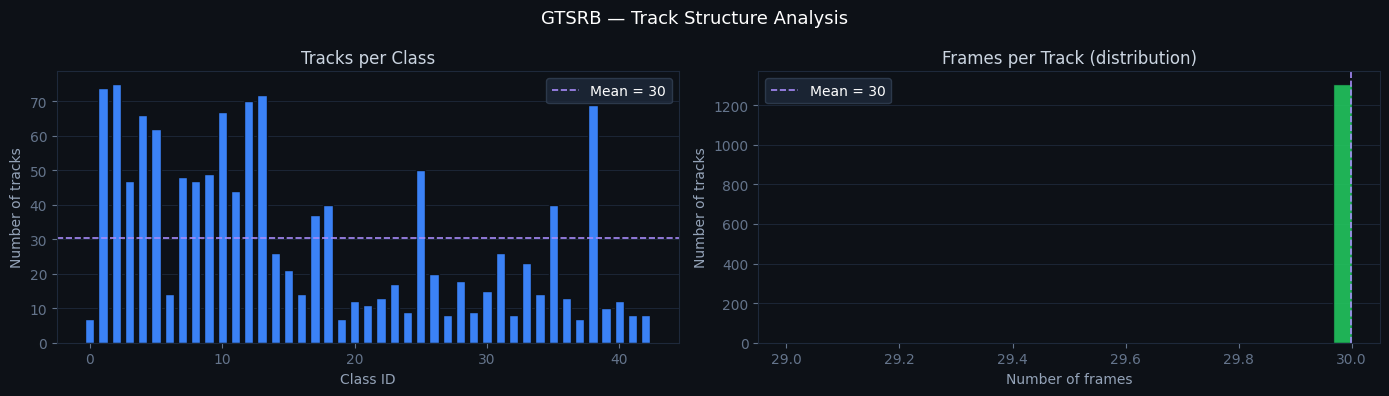

In [ ]:
# Extract track ID from filename: CCCCC_TTTTT_FFFFF.png
df["TrackId"] = df["Path"].apply(lambda p: "_".join(p.split("/")[-1].split("_")[:2]))

tracks_per_class = df.groupby("ClassId")["TrackId"].nunique()
frames_per_track = df.groupby("TrackId").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("GTSRB — Track Structure Analysis", color="white", fontsize=13)

# Plot 1: tracks per class
ax = axes[0]
ax.set_facecolor("#0d1117")
ax.bar(tracks_per_class.index, tracks_per_class.values, color="#3b82f6", edgecolor="#0d1117", width=0.7)
ax.axhline(tracks_per_class.mean(), color="#a78bfa", linestyle="--", linewidth=1.2,
           label=f"Mean = {tracks_per_class.mean():.0f}")
ax.set_title("Tracks per Class", color="#cbd5e1")
ax.set_xlabel("Class ID", color="#94a3b8")
ax.set_ylabel("Number of tracks", color="#94a3b8")
ax.tick_params(colors="#64748b")
ax.legend(labelcolor="white", facecolor="#1e293b", edgecolor="#334155")
for spine in ax.spines.values(): spine.set_color("#1e293b")
ax.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax.set_axisbelow(True)

# Plot 2: frames per track (histogram)
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
ax2.hist(frames_per_track.values, bins=30, color="#22c55e", edgecolor="#0d1117", alpha=0.9)
ax2.axvline(frames_per_track.mean(), color="#a78bfa", linestyle="--", linewidth=1.2,
            label=f"Mean = {frames_per_track.mean():.0f}")
ax2.set_title("Frames per Track (distribution)", color="#cbd5e1")
ax2.set_xlabel("Number of frames", color="#94a3b8")
ax2.set_ylabel("Number of tracks", color="#94a3b8")
ax2.tick_params(colors="#64748b")
ax2.legend(labelcolor="white", facecolor="#1e293b", edgecolor="#334155")
for spine in ax2.spines.values(): spine.set_color("#1e293b")
ax2.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax2.set_axisbelow(True)

# Print summary
print(f"Total unique tracks : {df['TrackId'].nunique()}")
print(f"Tracks per class    : min={tracks_per_class.min()}  max={tracks_per_class.max()}  mean={tracks_per_class.mean():.0f}")
print(f"Frames per track    : min={frames_per_track.min()}  max={frames_per_track.max()}  mean={frames_per_track.mean():.0f}")

plt.tight_layout()
# plt.savefig("track_structure.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

In [27]:
meta_csv_path = "/home/mohammmad/Traffic-Sign-Recognition /data/Meta.csv"
meta_df = pd.read_csv(meta_csv_path)
meta_df.head()

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


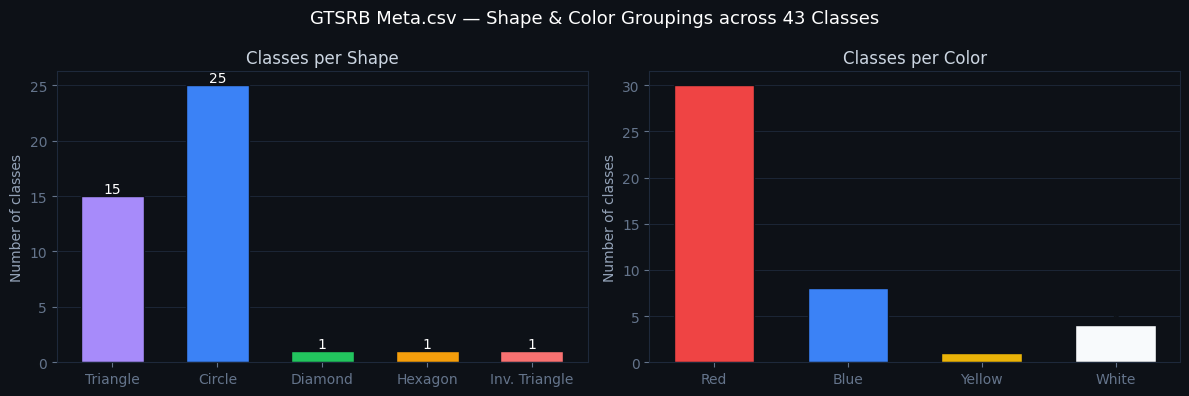

In [ ]:
meta = pd.read_csv(f"{DATA_DIR}/Meta.csv")

SHAPE_NAMES = {0: "Triangle", 1: "Circle", 2: "Diamond", 3: "Hexagon", 4: "Inv. Triangle"}
COLOR_NAMES = {0: "Red", 1: "Blue", 2: "Yellow", 3: "White"}
COLOR_HEX   = {0: "#ef4444", 1: "#3b82f6", 2: "#eab308", 3: "#f8fafc"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("GTSRB Meta.csv — Shape & Color Groupings across 43 Classes", color="white", fontsize=13)

# Plot 1: classes per shape
ax = axes[0]
ax.set_facecolor("#0d1117")
shape_counts = meta["ShapeId"].value_counts().sort_index()
bars = ax.bar(
    [SHAPE_NAMES[i] for i in shape_counts.index],
    shape_counts.values,
    color=["#a78bfa", "#3b82f6", "#22c55e", "#f59e0b", "#f87171"],
    edgecolor="#0d1117", width=0.6
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", color="white", fontsize=10)
ax.set_title("Classes per Shape", color="#cbd5e1")
ax.set_ylabel("Number of classes", color="#94a3b8")
ax.tick_params(colors="#64748b")
for spine in ax.spines.values(): spine.set_color("#1e293b")
ax.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax.set_axisbelow(True)

# Plot 2: classes per color
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
color_counts = meta["ColorId"].value_counts().sort_index()
bars2 = ax2.bar(
    [COLOR_NAMES[i] for i in color_counts.index],
    color_counts.values,
    color=[COLOR_HEX[i] for i in color_counts.index],
    edgecolor="#0d1117", width=0.6
)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha="center", color="#0d1117", fontsize=10, fontweight="bold")
ax2.set_title("Classes per Color", color="#cbd5e1")
ax2.set_ylabel("Number of classes", color="#94a3b8")
ax2.tick_params(colors="#64748b")
for spine in ax2.spines.values(): spine.set_color("#1e293b")
ax2.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax2.set_axisbelow(True)

plt.tight_layout()
# plt.savefig("meta_shape_color.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

**Brightness distribution per class**

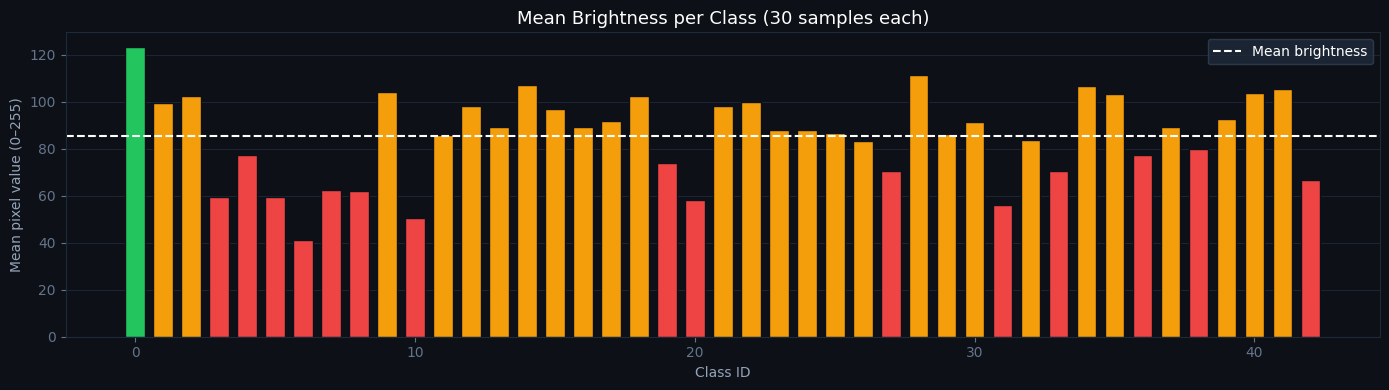

In [ ]:
df["Path"] = df["Path"].str.replace("Train/", "train/", regex=False)

brightness = {}
for class_id in range(43):
    sample = df[df["ClassId"] == class_id].sample(30, random_state=42)
    values = []
    for _, row in sample.iterrows():
        img = Image.open(f"{DATA_DIR}/{row['Path']}").convert("L")
        img = img.crop((row["Roi.X1"], row["Roi.Y1"], row["Roi.X2"], row["Roi.Y2"]))
        values.append(np.array(img).mean())
    brightness[class_id] = np.mean(values)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
colors = ["#ef4444" if v < 80 else "#f59e0b" if v < 120 else "#22c55e" for v in brightness.values()]
ax.bar(brightness.keys(), brightness.values(), color=colors, edgecolor="#0d1117", width=0.7)
ax.axhline(np.mean(list(brightness.values())), color="white", linestyle="--", label="Mean brightness")
ax.set_title("Mean Brightness per Class (30 samples each)", color="white", fontsize=13)
ax.set_xlabel("Class ID", color="#94a3b8")
ax.set_ylabel("Mean pixel value (0–255)", color="#94a3b8")
ax.tick_params(colors="#64748b")
ax.legend(labelcolor="white", facecolor="#1e293b", edgecolor="#334155")
for spine in ax.spines.values(): spine.set_color("#1e293b")
ax.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig("brightness_per_class.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

**Train vs Test class distribution**

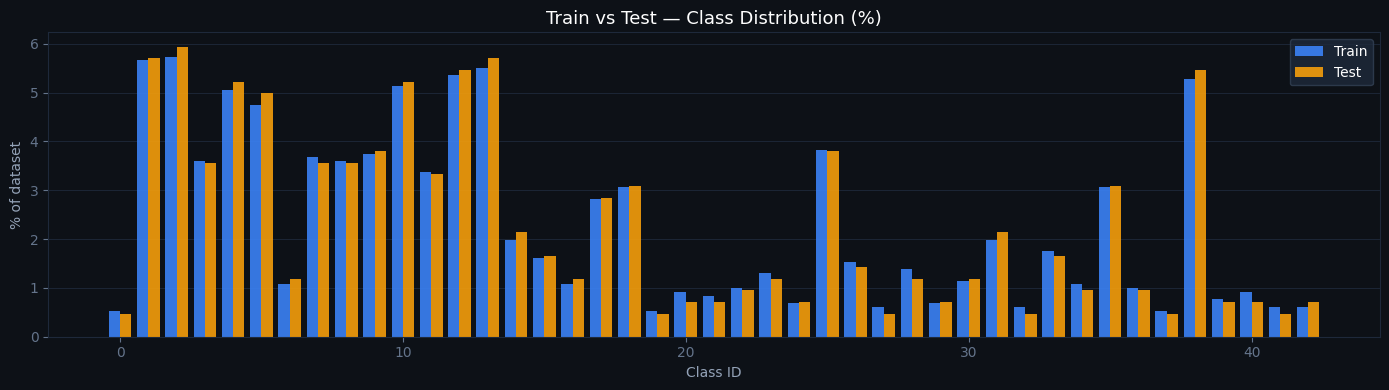

In [ ]:
df_train = pd.read_csv(f"{DATA_DIR}/Train.csv")
df_test  = pd.read_csv(f"{DATA_DIR}/Test.csv")

train_dist = df_train["ClassId"].value_counts(normalize=True).sort_index()
test_dist  = df_test["ClassId"].value_counts(normalize=True).sort_index()

x = np.arange(43)
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#0d1117")
ax.bar(x - 0.2, train_dist.values * 100, width=0.4, color="#3b82f6", label="Train", alpha=0.9)
ax.bar(x + 0.2, test_dist.values  * 100, width=0.4, color="#f59e0b", label="Test",  alpha=0.9)
ax.set_title("Train vs Test — Class Distribution (%)", color="white", fontsize=13)
ax.set_xlabel("Class ID", color="#94a3b8")
ax.set_ylabel("% of dataset", color="#94a3b8")
ax.tick_params(colors="#64748b")
ax.legend(labelcolor="white", facecolor="#1e293b", edgecolor="#334155")
for spine in ax.spines.values(): spine.set_color("#1e293b")
ax.yaxis.grid(True, color="#1e293b", linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig("train_vs_test_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

**Compute Mean & STD**

In [2]:
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

DATA_DIR = "../data"
df = pd.read_csv(f"{DATA_DIR}/Train.csv")
df["Path"] = df["Path"].str.replace("Train/", "train/", regex=False)

pixel_sum    = np.zeros(3)  # one value per channel R, G, B
pixel_sq_sum = np.zeros(3)
pixel_count  = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    img = Image.open(f"{DATA_DIR}/{row['Path']}").convert("RGB")
    img = img.crop((row["Roi.X1"], row["Roi.Y1"], row["Roi.X2"], row["Roi.Y2"]))
    img = img.resize((32, 32))
    arr = np.array(img) / 255.0         # shape: (32, 32, 3), values 0–1

    pixel_sum    += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    pixel_count  += 32 * 32             # 1024 pixels per image

mean = pixel_sum / pixel_count
std  = np.sqrt(pixel_sq_sum / pixel_count - mean ** 2)

print(f"MEAN = {mean.tolist()}")
print(f"STD  = {std.tolist()}")

100%|██████████| 39209/39209 [00:16<00:00, 2379.08it/s]

MEAN = [0.3586026519084019, 0.31745679806375865, 0.3353860326349692]
STD  = [0.2738793602624722, 0.25774299920137855, 0.26788354220321686]
